# Temporal aggregation — TensorFlow (loads saved Keras V1)

Loads `v1_model.keras`, scores continuous timelines one window every 0.5 s, and computes a rolling **SMM-rate** that rises during sustained stereotypy; crossing `ALERT_LEVEL` is the pre-meltdown alert.

*Note:* ASDMotion has no meltdown timestamps, so this demonstrates the deployment mechanism and shows the rate tracks SMM density; meltdown-timed validation is out of scope (stated limitation).

In [1]:
# ── Config ───────────────────────────────────────────────────────────
OUT_DIR     = "prepared"      # prep arrays + the saved Keras model live here
PKL_PATH    = "dataset.pkl"   # original annotated pickle (raw skeletons)
MAX_GAP     = 4
MAX_INVALID = 0.5
FPS         = 30
STRIDE_FINE = 15              # score one window every STRIDE_FINE frames (0.5 s)
ROLL_SECONDS = 20            # rolling window for the SMM-rate
ALERT_LEVEL  = 0.5           # alert when the rolling rate crosses this

In [2]:
# ── Imports, prep helpers, scaler, and the saved Keras V1 model ──────
import os, json, pickle
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import numpy as np, tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

ch = json.load(open(f"{OUT_DIR}/channels.json"))
L, N_SP = ch["L"], len(ch["kept_keypoints"])
sc = json.load(open(f"{OUT_DIR}/scaler.json"))
MED = np.array(sc["speed_median"]); IQR = np.array(sc["speed_iqr"]); CAP = np.array(sc["speed_cap"])
THRESHOLD = json.load(open(f"{OUT_DIR}/v1_meta.json"))["threshold"]

@tf.keras.utils.register_keras_serializable()
class Augment(layers.Layer):
    """Same train-only augmentation layer used in training; identity at inference.
    Defined here so load_model can reconstruct the saved graph."""
    def __init__(self, noise=0.05, scale=0.10, kp_drop_p=0.12, shift=4, n_sp=10, **kw):
        super().__init__(**kw)
        self.noise, self.scale, self.kp_drop_p, self.shift, self.n_sp = noise, scale, kp_drop_p, shift, n_sp
    def call(self, x, training=None):
        if not training:
            return x
        b = tf.shape(x)[0]
        sp, cf = x[..., :self.n_sp], x[..., self.n_sp:]
        sp = sp + tf.random.normal(tf.shape(sp), 0.0, self.noise)
        sp = sp * tf.random.uniform([b, 1, 1], 1 - self.scale, 1 + self.scale)
        keep = tf.cast(tf.random.uniform([b, 1, self.n_sp]) > self.kp_drop_p, x.dtype)
        x = tf.concat([sp * keep, cf * keep], axis=-1)
        return tf.roll(x, tf.random.uniform([], -self.shift, self.shift + 1, dtype=tf.int32), axis=1)
    def get_config(self):
        c = super().get_config()
        c.update(noise=self.noise, scale=self.scale, kp_drop_p=self.kp_drop_p,
                 shift=self.shift, n_sp=self.n_sp); return c

model = tf.keras.models.load_model(f"{OUT_DIR}/v1_model.keras", custom_objects={"Augment": Augment})
print(f"window={L}  keypoints={N_SP}  threshold={THRESHOLD:.3f}  | Keras V1 model loaded")

# ── prep constants + feature helpers (same as prep notebook) ──
KP_NAMES = ["nose", "left_eye", "right_eye", "left_ear", "right_ear",
            "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
            "left_wrist", "right_wrist", "left_hip", "right_hip",
            "left_knee", "right_knee", "left_ankle", "right_ankle"]
KEEP = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
KEEP_NAMES = [KP_NAMES[i] for i in KEEP]
L_SH, R_SH, L_HIP, R_HIP = 5, 6, 11, 12

PURE_LOWER = {"Toe walking", "Legs movement"}   # dropped from positives

# Gross-motor (speed-visible) SMM tokens; a positive segment counts as
# gross-motor if its action set intersects this. Everything else positive
# (Fingers, Feeling texture, Playing with object, Tapping, Tremor, Other) is
# "fine-motor" -> dropped from V2's positive class, kept for per-category eval.
GROSS = {"Hand flapping", "Clapping", "Jumping in place", "Spinning in circle",
         "Back and forth", "Body rocking", "Head movement"}


# ----------------------------------------------------------------------
# per-segment scale
# ----------------------------------------------------------------------

def segment_scale(kp, min_frames=5):
    """Single robust scale (px) for a segment. Returns (scale, method) or (None, 'fail')."""
    def real(i):
        return ~((kp[:, i, 0] == 0) & (kp[:, i, 1] == 0))

    sh = real(L_SH) & real(R_SH)
    if sh.sum() >= min_frames:
        w = np.linalg.norm(kp[sh, L_SH, :] - kp[sh, R_SH, :], axis=1)
        w = w[w > 1e-6]
        if w.size >= min_frames:
            return float(np.median(w)), "shoulder"

    hp = real(L_HIP) & real(R_HIP)
    both = sh & hp
    if both.sum() >= min_frames:
        msh = (kp[:, L_SH, :] + kp[:, R_SH, :]) / 2
        mhip = (kp[:, L_HIP, :] + kp[:, R_HIP, :]) / 2
        tor = np.linalg.norm(msh[both] - mhip[both], axis=1)
        tor = tor[tor > 1e-6]
        if tor.size >= min_frames:
            return float(np.median(tor)), "torso"

    pts = kp[:, KEEP, :]
    realk = ~((pts[..., 0] == 0) & (pts[..., 1] == 0))   # (T,10)
    spreads = []
    for t in range(pts.shape[0]):
        m = realk[t]
        if m.sum() >= 3:
            p = pts[t, m, :]
            spreads.append(max(np.ptp(p[:, 0]), np.ptp(p[:, 1])))
    if spreads:
        s = float(np.median(spreads))
        if s > 1e-6:
            return s, "bbox"
    return None, "fail"


# ----------------------------------------------------------------------
# short-gap linear interpolation
# ----------------------------------------------------------------------
def interp_gaps(coords, valid, max_gap):
    """coords (T,2), valid (T,) bool. Linearly fill interior gaps <= max_gap."""
    T = len(valid)
    c = coords.copy()
    v = valid.copy()
    t = 0
    while t < T:
        if v[t]:
            t += 1
            continue
        s = t
        while t < T and not v[t]:
            t += 1
        e = t                       # invalid run is [s, e)
        gap = e - s
        if s > 0 and e < T and gap <= max_gap:
            x0, x1 = c[s - 1], c[e]
            for j in range(gap):
                a = (j + 1) / (gap + 1)
                c[s + j] = x0 * (1 - a) + x1 * a
                v[s + j] = True
    return c, v


# ----------------------------------------------------------------------
# process one segment -> speed (T,10), conf (T,10), speed_valid (T,10) or None
# ----------------------------------------------------------------------
def process_segment(rec, max_gap):
    kp = np.asarray(rec["keypoint"], dtype=np.float64)      # (T,17,2)
    sc = np.asarray(rec["keypoint_score"], dtype=np.float64)  # (T,17)
    fps = float(rec.get("fps", 30.0))
    T = kp.shape[0]

    scale, method = segment_scale(kp)
    if scale is None:
        return None

    P = kp[:, KEEP, :]                                      # (T,10,2)
    realk = ~((P[..., 0] == 0) & (P[..., 1] == 0))          # (T,10)
    Pn = P / scale

    valid = realk.copy()
    for k in range(len(KEEP)):
        Pn[:, k, :], valid[:, k] = interp_gaps(Pn[:, k, :], realk[:, k], max_gap)

    dt = 1.0 / fps
    speed = np.zeros((T, len(KEEP)), dtype=np.float64)
    both = valid[1:] & valid[:-1]                           # (T-1,10)
    d = np.linalg.norm(Pn[1:] - Pn[:-1], axis=2)            # (T-1,10)
    speed[1:] = np.where(both, d / dt, 0.0)
    speed_valid = np.zeros((T, len(KEEP)), dtype=bool)
    speed_valid[1:] = both

    conf = np.clip(sc[:, KEEP], 0.0, 1.0)
    return speed, conf, speed_valid, method


# ----------------------------------------------------------------------
# window generator
# ----------------------------------------------------------------------

I0000 00:00:1783485113.389304   75780 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783485114.862455   75780 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


window=90  keypoints=10  threshold=0.082  | Keras V1 model loaded


E0000 00:00:1783485118.226070   75780 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


In [3]:
# ── Dense scoring: list of segments → continuous per-window stream ───
def score_timeline(recs):
    """recs laid end-to-end → window centre-times (s), SMM probabilities,
    ground-truth SMM flag per window, validity flag."""
    xs, times, gt, valid = [], [], [], []
    t_off = 0.0
    for rec in recs:
        out = process_segment(rec, MAX_GAP)
        if out is None:
            t_off += rec["keypoint"].shape[0] / FPS
            continue
        speed, conf, sv, _ = out
        T = speed.shape[0]
        for start in range(0, T - L + 1, STRIDE_FINE):
            sl = slice(start, start + L)
            sp = (np.minimum(speed[sl], CAP) - MED) / IQR        # robust scaler (train stats)
            xs.append(np.concatenate([sp, conf[sl]], axis=1).astype("float32"))  # (L, 20) channels-last
            times.append(t_off + (start + L / 2) / FPS)
            gt.append(int(rec.get("binary_label", 0)))
            valid.append((1.0 - sv[sl].mean()) <= MAX_INVALID)
        t_off += T / FPS
    if not xs:
        return None
    probs = model.predict(np.stack(xs), batch_size=512, verbose=0).ravel()
    return dict(t=np.array(times), p=probs, gt=np.array(gt), valid=np.array(valid))

In [4]:
# ── Rolling SMM-rate + alerts + plotting ─────────────────────────────
def rolling_rate(stream, roll_seconds):
    """Causal trailing mean of the SMM probability over roll_seconds."""
    p, t = stream["p"], stream["t"]
    dt = STRIDE_FINE / FPS
    n = max(1, int(round(roll_seconds / dt)))
    csum = np.cumsum(np.insert(p, 0, 0.0))
    rate = np.array([(csum[i + 1] - csum[max(0, i + 1 - n)]) / min(i + 1, n)
                     for i in range(len(p))])
    return rate

def alert_regions(t, rate, level):
    on = rate >= level
    regions, s = [], None
    for i, a in enumerate(on):
        if a and s is None: s = t[i]
        if not a and s is not None: regions.append((s, t[i])); s = None
    if s is not None: regions.append((s, t[-1]))
    return regions

def plot_timeline(stream, title, roll_seconds=None, level=None):
    roll_seconds = roll_seconds or ROLL_SECONDS
    level = ALERT_LEVEL if level is None else level
    t, p, gt = stream["t"], stream["p"], stream["gt"]
    rate = rolling_rate(stream, roll_seconds)
    fig, ax = plt.subplots(figsize=(12, 3.4))
    # ground-truth SMM shading (light) so we can see if the rate tracks it
    in_smm, s = False, None
    for i in range(len(t)):
        if gt[i] and not in_smm: s, in_smm = t[i], True
        if not gt[i] and in_smm: ax.axvspan(s, t[i], color="orange", alpha=0.10); in_smm = False
    if in_smm: ax.axvspan(s, t[-1], color="orange", alpha=0.10)
    ax.plot(t, p, color="gray", alpha=0.35, lw=0.8, label="per-window SMM prob")
    ax.plot(t, rate, color="crimson", lw=2.2, label=f"rolling SMM-rate ({roll_seconds}s)")
    ax.axhline(level, color="black", ls="--", lw=1, label=f"alert level {level}")
    for a, b in alert_regions(t, rate, level):
        ax.axvspan(a, b, color="red", alpha=0.18)
    ax.set_title(title); ax.set_xlabel("time (s)"); ax.set_ylabel("SMM probability / rate")
    ax.set_ylim(-0.02, 1.02); ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    slug = "".join(c if c.isalnum() else "_" for c in title)[:40]
    fig.savefig(f"{OUT_DIR}/timeline_{slug}.png", dpi=120); plt.show()
    # how well does the rate separate true SMM from NoAction windows?
    if (gt == 1).any() and (gt == 0).any():
        print(f"  mean rolling-rate during SMM={rate[gt==1].mean():.3f}  "
              f"during NoAction={rate[gt==0].mean():.3f}")
    return rate

=== sustained SMM clip ===


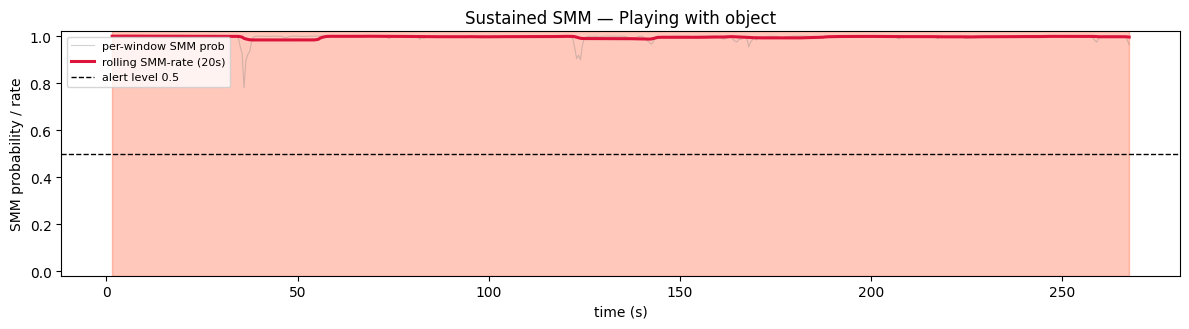

=== calm baseline clip ===


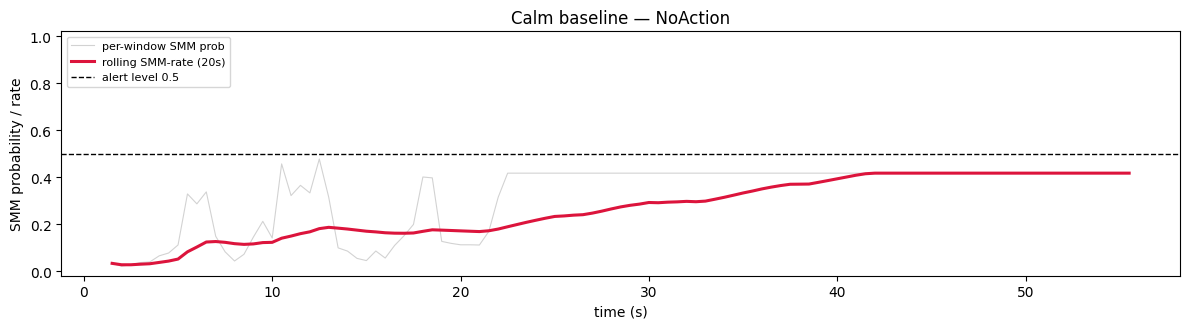

=== constructed arc (subject 198: calm -> SMM -> calm) ===


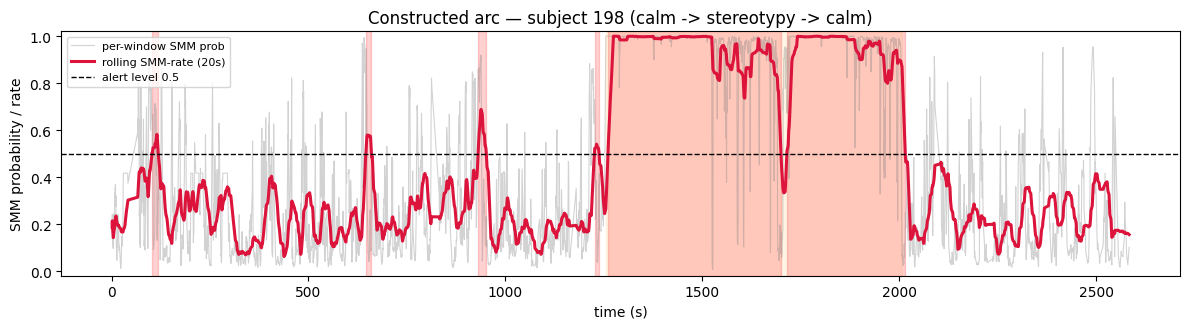

  mean rolling-rate during SMM=0.929  during NoAction=0.248

The rate climbs through the alert level during stereotypy and falls back as the child settles — the full escalate-then-recover arc.


In [5]:
# ── Demonstration timelines ──────────────────────────────────────────
obj = pickle.load(open(PKL_PATH, "rb"))
anns = obj["annotations"]
test_ids = set(obj["split"]["test"])
test = [r for r in anns if r.get("identifier") in test_ids]
subj = lambda r: str(r["identifier"]).split("_")[0]

# 1) sanity checks: a sustained SMM clip and a calm clip
smm = max((r for r in test if r["binary_label"] == 1), key=lambda r: r["keypoint"].shape[0])
noa = max((r for r in test if r["binary_label"] == 0), key=lambda r: r["keypoint"].shape[0])
print("=== sustained SMM clip ===")
plot_timeline(score_timeline([smm]), f"Sustained SMM — {smm['action_name']}")
print("=== calm baseline clip ===")
plot_timeline(score_timeline([noa]), "Calm baseline — NoAction")

# 2) full arc: calm -> SMM -> calm (rate rises through the alert, then recovers)
from collections import Counter
cand = [s for s in Counter(subj(r) for r in test)
        if any(subj(r) == s and r["binary_label"] == 1 for r in test)
        and any(subj(r) == s and r["binary_label"] == 0 for r in test)]
s0 = max(cand, key=lambda s: sum(r["keypoint"].shape[0] for r in test
                                 if subj(r) == s and r["binary_label"] == 1))
calm = sorted([r for r in test if subj(r) == s0 and r["binary_label"] == 0],
              key=lambda r: -r["keypoint"].shape[0])
smms = sorted([r for r in test if subj(r) == s0 and r["binary_label"] == 1],
              key=lambda r: -r["keypoint"].shape[0])[:4]
if len(calm) >= 2:                                   # split calm: some before, some after
    mid = len(calm) // 2
    pre, post = calm[:mid], calm[mid:]
else:                                                # only one calm clip -> reuse at both ends
    pre = post = calm
print(f"=== constructed arc (subject {s0}: calm -> SMM -> calm) ===")
plot_timeline(score_timeline(pre + smms + post),
              f"Constructed arc — subject {s0} (calm -> stereotypy -> calm)")
print("\nThe rate climbs through the alert level during stereotypy and falls back "
      "as the child settles — the full escalate-then-recover arc.")